<a href="https://colab.research.google.com/github/aiyman14/Sch-Mgmt-661-Applications-of-AI-Models/blob/main/W6_NLP_Foundations_BoW_TF_IDF_N_grams_Shared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SCH-MGMT 661: Applications of AI Models  
**Instructor:** Indika Dissanayake  

---

## Tutorial: NLP Foundations — Text Pre-Processing, BoW, TF-IDF, and N-grams
**Dataset:** Inside Airbnb – Asheville Reviews

---

In this tutorial, we will build the foundation for working with text data in Natural Language Processing (NLP). Unlike numeric data, text must first be cleaned, tokenized, and transformed into numerical representations that machine learning models can understand.

By the end of this notebook, you will learn how to:

* Perform basic text pre-processing (lowercasing, punctuation removal, stopwords, etc.)

* Apply tokenization to split text into words
* Represent text using:
    * Bag-of-Words (BoW): simple word counts
    * TF-IDF (Term Frequency–Inverse Document Frequency): weighting frequent but less informative words lower
    * N-grams: capturing short phrases like bigrams and trigrams

We will work with Airbnb guest reviews from the Asheville dataset (Inside Airbnb project). Reviews provide unstructured text that is perfect for practicing NLP techniques.

## Load and Preview the Data

We will start by loading the Airbnb reviews dataset.  
Each row represents a guest review for a particular listing.  

Since we want to analyze reviews at the **listing level**, we’ll take the **latest 5 reviews per listing** and combine them into a single text document.  
To keep this tutorial efficient and easy to follow, we’ll also select a **random sample of 100 listings** for demonstration purposes.



In [1]:
import pandas as pd

# import Ashville reviews datasets
reviews_url = 'https://data.insideairbnb.com/united-states/nc/asheville/2024-06-21/data/reviews.csv.gz'

# Load the datasets into DataFrames
reviews_df = pd.read_csv(reviews_url, compression='gzip')


# Sort by listing and date, then keep the latest 5 reviews per listing
reviews_df['date'] = pd.to_datetime(reviews_df['date']) # change data type
latest_reviews = (reviews_df.sort_values(['listing_id', 'date'], ascending=[True, False])
                  .groupby('listing_id')
                  .head(5))

# Combine reviews into a single document per listing
listing_texts = latest_reviews.groupby('listing_id')['comments'].apply(
    lambda x: " ".join(x.astype(str))
).reset_index(name='combined_reviews')

# Preview results
print("Shape of dataset:", listing_texts.shape)
listing_texts.head()


Shape of dataset: (2812, 2)


,listing_id,combined_reviews
0,155305,great place to stay to meet other people trave...
1,156805,This hostel was awesome. It was well located t...
2,156926,Great hostel Great place!!! Will stay here ag...
3,197263,"Timo is a great host, have stayed with him twi..."
4,209068,Kevin was a very responsive host. This is a co...


In [2]:
# Let's select a random sample of 100 listingd for the demostration purpose

small_sample = listing_texts.sample(n=100, random_state=42)
print(small_sample.shape)



(100, 2)


## Text Preprocessing

Raw reviews often contain punctuation, capitalization, numbers, and stopwords (common words like *the, is, at*).  
Before applying NLP techniques such as Bag-of-Words or TF-IDF, we need to clean and standardize the text.  

In this step, we will:  
1. Convert text to lowercase  
2. Remove punctuation and numbers  
3. Remove common stopwords  
4. (Optional) Apply stemming or lemmatization — reducing words to their root form (*running → run*)  



In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download stopwords & wordnet if not already
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
small_sample["cleaned_reviews"] = small_sample["combined_reviews"].apply(preprocess_text)

# Preview results
small_sample[["combined_reviews", "cleaned_reviews"]].head(5)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,combined_reviews,cleaned_reviews
402,The stay was lovely. I was in town for a confe...,stay lovely town conference exactly needed con...
2259,We spent a little over a month working remotel...,spent little month working remotely exploring ...
1190,Best location in town. May be the best AirBnB...,best location town may best airbnb ever stayed...
296,Great stay! Thank you! We had a fabulous last ...,great stay thank fabulous last minute get away...
1099,"Lovely place—perfect for my husband, me and ou...",lovely placeperfect husband two poodle close b...


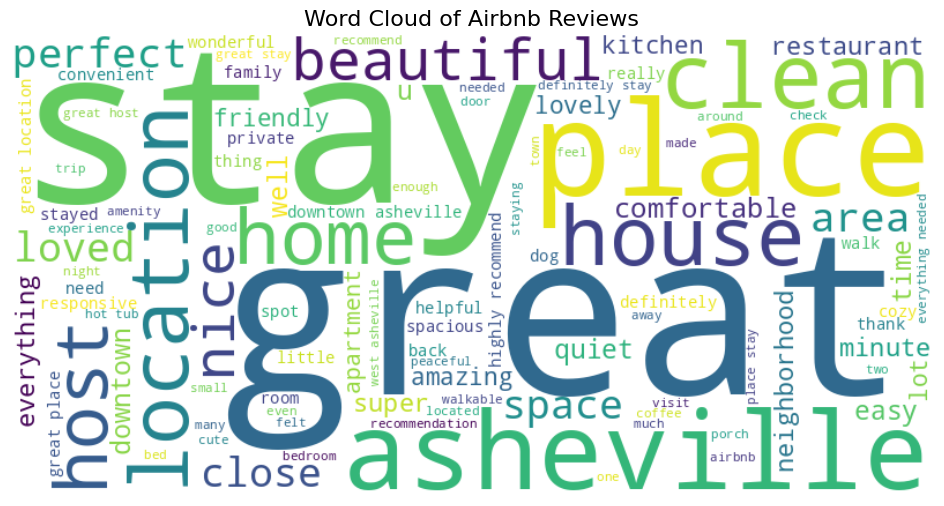

In [4]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all clenaed reviews into one big text
all_text = " ".join(small_sample["cleaned_reviews"])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white",
                      max_words=100, colormap="viridis").generate(all_text)

# Display
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Airbnb Reviews", fontsize=16)
plt.show()


### Reflection Exercise  

Look at the original reviews and the cleaned reviews side by side.  

- What information did we lose during preprocessing (e.g., punctuation, capitalization)?  
- Why might removing stopwords or punctuation help the model?  
- Are there cases where too much cleaning might actually remove useful meaning (e.g., sentiment in words like "not")?  


## Bag-of-Words (Word Counts)

The Bag-of-Words model represents text by counting how many times each word appears.  
- It ignores word order, grammar, and context.  
- Each document becomes a vector of word frequencies.  
- While simple, it often works surprisingly well for tasks like sentiment classification or topic clustering.  

We will use `CountVectorizer` from **scikit-learn** to transform our Airbnb reviews into a document-term matrix.


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize vectorizer (limit vocab size for demo)
vectorizer = CountVectorizer(max_features=20, stop_words='english')

# Fit and transform cleaned reviews
bow_matrix = vectorizer.fit_transform(small_sample['cleaned_reviews'])

# Convert to DataFrame for readability
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

print("Shape of BoW matrix:", bow_df.shape)
bow_df.head(10)


Shape of BoW matrix: (100, 20)


,asheville,beautiful,clean,close,comfortable,definitely,downtown,easy,great,home,host,house,location,loved,nice,perfect,place,recommend,space,stay
0,1,0,1,0,0,0,0,0,1,0,2,1,2,0,1,2,1,1,3,5
1,2,1,0,2,1,0,2,2,2,2,0,5,3,2,0,6,0,0,3,3
2,2,1,1,0,0,1,2,0,1,1,1,0,2,0,1,1,0,0,0,2
3,2,2,2,2,0,2,0,0,3,1,0,1,0,2,2,2,3,1,1,5
4,5,0,1,2,1,2,1,1,5,1,2,0,1,2,0,2,4,0,1,5
5,2,0,2,0,0,2,1,1,1,1,0,6,0,1,1,0,2,1,1,3
6,3,3,1,0,1,2,3,1,3,0,3,1,1,1,0,2,4,2,2,3
7,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
8,2,2,4,0,3,1,1,0,3,1,1,0,2,1,0,1,3,1,0,0
9,2,0,1,2,2,1,0,0,1,6,2,1,2,0,0,1,4,1,1,1


## TF-IDF (Term Frequency–Inverse Document Frequency)

Bag-of-Words gives us raw counts of words, but it does not distinguish between **common words** (like *room*, *place*, *stay*) and more **meaningful words**.  

TF-IDF improves on this by weighting words based on two factors:  

- **Term Frequency (TF):** How often a word appears in a single document.  
- **Inverse Document Frequency (IDF):** How rare the word is across the entire collection of documents.  

### Why it matters
- Words that are frequent in a single review but rare across all reviews (e.g., *fireplace*, *mountain*, *cozy*) receive **higher importance**.  
- Very common words that appear in nearly every review (e.g., *room*, *good*, *stay*) are **downweighted**.  

### Key Takeaway
TF-IDF highlights the **most distinctive words** in reviews, giving us a more meaningful text representation for analysis and modeling.  

We will now apply TF-IDF to our Airbnb sample reviews and inspect the top weighted words.


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Apply TF-IDF
tfidf = TfidfVectorizer(max_features=20, stop_words='english')
X_tfidf = tfidf.fit_transform(small_sample['cleaned_reviews'])

# Convert to DataFrame for inspection
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Show top rows
print("TF-IDF matrix (first 5 rows):")
display(tfidf_df.head())


TF-IDF matrix (first 5 rows):


,asheville,beautiful,clean,close,comfortable,definitely,downtown,easy,great,home,host,house,location,loved,nice,perfect,place,recommend,space,stay
0,0.120878,0.000000,0.128460,0.000000,0.000000,0.000000,0.000000,0.000000,0.110476,0.000000,0.303993,0.180515,0.254312,0.000000,0.178342,0.317699,0.123343,0.176214,0.548207,0.536167
1,0.140930,0.103963,0.000000,0.189409,0.085778,0.000000,0.164413,0.191571,0.128802,0.187286,0.000000,0.526151,0.222375,0.196017,0.000000,0.555604,0.000000,0.000000,0.319574,0.187533
2,0.364544,0.268921,0.193705,0.000000,0.000000,0.236879,0.425287,0.000000,0.166586,0.242226,0.229196,0.000000,0.383477,0.000000,0.268921,0.239529,0.000000,0.000000,0.000000,0.323394
3,0.200474,0.295776,0.213048,0.269434,0.000000,0.260534,0.000000,0.000000,0.274832,0.133207,0.000000,0.149690,0.000000,0.278834,0.295776,0.263449,0.306842,0.146124,0.151531,0.444610
4,0.441691,0.000000,0.093879,0.237451,0.107535,0.229607,0.103058,0.120081,0.403680,0.117395,0.222159,0.000000,0.092926,0.245735,0.000000,0.232176,0.360557,0.000000,0.133544,0.391833


### Reflection Exercise  

Take a look at the TF-IDF matrix above. Each row represents a listing (combined reviews), and each column represents a word from our vocabulary. The numbers indicate how important a word is for that listing compared to all others.


- Do you notice which words have higher TF-IDF scores for certain listings?

- How does this differ from the Bag-of-Words matrix, where we only saw raw counts?

- Which representation (BoW or TF-IDF) do you think better captures the distinctiveness of reviews?

## N-grams (Bigrams & Trigrams)

So far, we’ve represented text as individual words (**unigrams**).  
However, meaning often comes from **sequences of words** rather than single terms.  

For example:  
- *"new york"* has a different meaning than just *"new"* and *"york"*.  
- *"very good"* conveys stronger sentiment than just *"very"* or *"good"*.  

### What are N-grams?
- **Unigram (n=1):** Single words → “good”, “location”, “clean”  
- **Bigram (n=2):** Two-word sequences → “great location”, “very clean”  
- **Trigram (n=3):** Three-word sequences → “easy to checkin”, “close to downtown”  

### Why use N-grams?
N-grams capture **phrases and context**, making them more informative for understanding text compared to isolated words.  
They are especially useful in sentiment analysis, topic modeling, and search engines where meaning depends on word combinations.  

In the next step, we will generate **bigrams and trigrams** from the Airbnb reviews and explore the most common ones.


In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Use bigrams and trigrams (n=2 and n=3)
ngram_vectorizer = CountVectorizer(ngram_range=(2,3), stop_words='english', max_features=30)

# Fit and transform on the cleaned reviews
X_ngrams = ngram_vectorizer.fit_transform(small_sample['cleaned_reviews'])

# Convert to dataframe
ngrams_df = pd.DataFrame(X_ngrams.toarray(), columns=ngram_vectorizer.get_feature_names_out())

# Get the top n-grams by summing across all documents
top_ngrams = ngrams_df.sum().sort_values(ascending=False).head(20)

print("Top 20 most frequent bigrams and trigrams:")
print(top_ngrams)


Top 20 most frequent bigrams and trigrams:
downtown asheville    38
great location        36
highly recommend      35
great place           33
great stay            29
definitely stay       29
place stay            28
hot tub               24
west asheville        22
great host            21
stay great            19
place perfect         19
enjoyed stay          19
stay asheville        18
clean comfortable     17
walking distance      15
really enjoyed        15
wonderful stay        14
bed comfortable       13
comfortable bed       13
dtype: int64


### Reflection Exercise

- Notice how n-grams capture common phrases, not just single words. For example, phrases like “great location” or “highly recommend” tell us more than the single words “great” or “recommend.”

- Compared to single words, phrases give us a richer view of context — they show what was positive (location, stay, host) and make the meaning clearer.